In [ ]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

# DataSet INFO

In [ ]:
# getting dataset
# df = pd.read_csv("credit_card_approval.csv")
df=pd.read_csv("/content/credit_card_approval.csv")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB,BEGIN_MONTHS,STATUS,TARGET
0,5065438,F,Y,N,2+ children,270000.0,Secondary / secondary special,Married,With parents,-13258,-2300,1,0,0,0,Managers,-6,C,0
1,5142753,F,N,N,No children,81000.0,Secondary / secondary special,Single / not married,House / apartment,-17876,-377,1,1,1,0,Private service staff,-4,0,0
2,5111146,M,Y,Y,No children,270000.0,Higher education,Married,House / apartment,-19579,-1028,1,0,1,0,Laborers,0,C,0
3,5010310,F,Y,Y,1 children,112500.0,Secondary / secondary special,Married,House / apartment,-15109,-1956,1,0,0,0,Core staff,-3,0,0
4,5010835,M,Y,Y,2+ children,139500.0,Secondary / secondary special,Married,House / apartment,-17281,-5578,1,1,0,0,Drivers,-29,0,0


In [ ]:
df.shape

(537667, 19)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537667 entries, 0 to 537666
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   537667 non-null  int64  
 1   CODE_GENDER          537667 non-null  object 
 2   FLAG_OWN_CAR         537667 non-null  object 
 3   FLAG_OWN_REALTY      537667 non-null  object 
 4   CNT_CHILDREN         537667 non-null  object 
 5   AMT_INCOME_TOTAL     537667 non-null  float64
 6   NAME_EDUCATION_TYPE  537667 non-null  object 
 7   NAME_FAMILY_STATUS   537667 non-null  object 
 8   NAME_HOUSING_TYPE    537667 non-null  object 
 9   DAYS_BIRTH           537667 non-null  int64  
 10  DAYS_EMPLOYED        537667 non-null  int64  
 11  FLAG_MOBIL           537667 non-null  int64  
 12  FLAG_WORK_PHONE      537667 non-null  int64  
 13  FLAG_PHONE           537667 non-null  int64  
 14  FLAG_EMAIL           537667 non-null  int64  
 15  JOB              

In [ ]:
df.select_dtypes('number').columns

Index(['ID', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'BEGIN_MONTHS',
       'TARGET'],
      dtype='object')

In [ ]:
df.replace("?", np.nan, inplace=True)

In [ ]:
df.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
DAYS_BIRTH,0


In [ ]:
numerical = df.select_dtypes(include='number').columns
categorical = df.select_dtypes(exclude='number').columns


# Text Data Preprocessing


In [ ]:
# Getting Unique VAlues for Each Col
for col in categorical:
    print(f"\n{col}:")
    print(df[col].unique())


CODE_GENDER:
['F' 'M']

FLAG_OWN_CAR:
['Y' 'N']

FLAG_OWN_REALTY:
['N' 'Y']

CNT_CHILDREN:
['2+ children' 'No children' '1 children']

NAME_EDUCATION_TYPE:
['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']

NAME_FAMILY_STATUS:
['Married' 'Single / not married' 'Civil marriage' 'Separated' 'Widow']

NAME_HOUSING_TYPE:
['With parents' 'House / apartment' 'Rented apartment'
 'Municipal apartment' 'Co-op apartment' 'Office apartment']

JOB:
['Managers' 'Private service staff' 'Laborers' 'Core staff' 'Drivers'
 'High skill tech staff' 'Realty agents' 'Secretaries' 'Accountants'
 'Sales staff' 'Medicine staff' 'Waiters/barmen staff'
 'Low-skill Laborers' 'Cleaning staff' 'HR staff' 'Cooking staff'
 'Security staff' 'IT staff']

STATUS:
['C' '0' 'X' '2' '1' '5' '3' '4']


In [1]:
# # Encoding
# binary_cols = ["CODE_GENDER","FLAG_OWN_CAR","FLAG_OWN_REALTY"]
# for col in binary_cols:
#   df[col] = df[col].map({"F": 0, "M": 1} if col == "CODE_GENDER" else {"N": 0, "Y": 1})


In [ ]:
# # Label Encoding
# cat_cols= ['CNT_CHILDREN','NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','STATUS']
# le = LabelEncoder()
# for col in cat_cols:
#   df[col] = le.fit_transform(df[col])



In [ ]:
# # One-Hot Encoding
# le2 = OneHotEncoder()
# df = pd.get_dummies(df, columns=["JOB"], drop_first=True)

# Numerical Preprocessing


In [ ]:
df[numerical]

,ID,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,BEGIN_MONTHS,TARGET
0,5065438,270000.0,-13258,-2300,1,0,0,0,-6,0
1,5142753,81000.0,-17876,-377,1,1,1,0,-4,0
2,5111146,270000.0,-19579,-1028,1,0,1,0,0,0
3,5010310,112500.0,-15109,-1956,1,0,0,0,-3,0
4,5010835,139500.0,-17281,-5578,1,1,0,0,-29,0
...,...,...,...,...,...,...,...,...,...,...
537662,5142999,166500.0,-12372,-5401,1,0,1,0,-8,0
537663,5010773,135000.0,-14160,-4635,1,0,0,0,-8,0
537664,5105601,180000.0,-24204,-2462,1,0,0,0,-7,0
537665,5132833,220500.0,-22647,-3847,1,0,1,0,-1,0


In [ ]:
# days_cols =['DAYS_BIRTH','DAYS_EMPLOYED','BEGIN_MONTHS']
days_cols =['DAYS_BIRTH','DAYS_EMPLOYED']
for col in days_cols:
  df[col] = (-df[col])


In [ ]:
df["AGE"] = df['DAYS_BIRTH'] / 365
df["EMPLOYED_YEARS"] = df['DAYS_EMPLOYED'] / 365
X = X.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"])

In [ ]:
num_cols = [
    "AMT_INCOME_TOTAL",
    "AGE",
    "EMPLOYED_YEARS",
    "BEGIN_MONTHS"
]

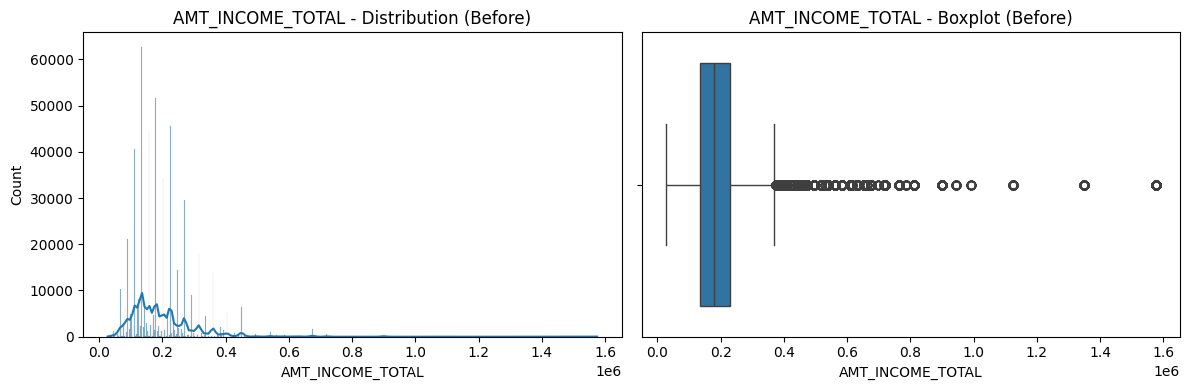

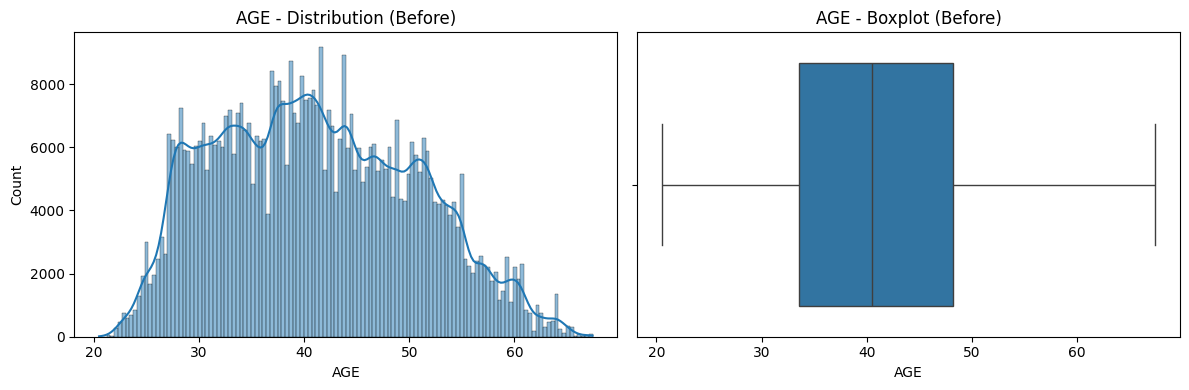

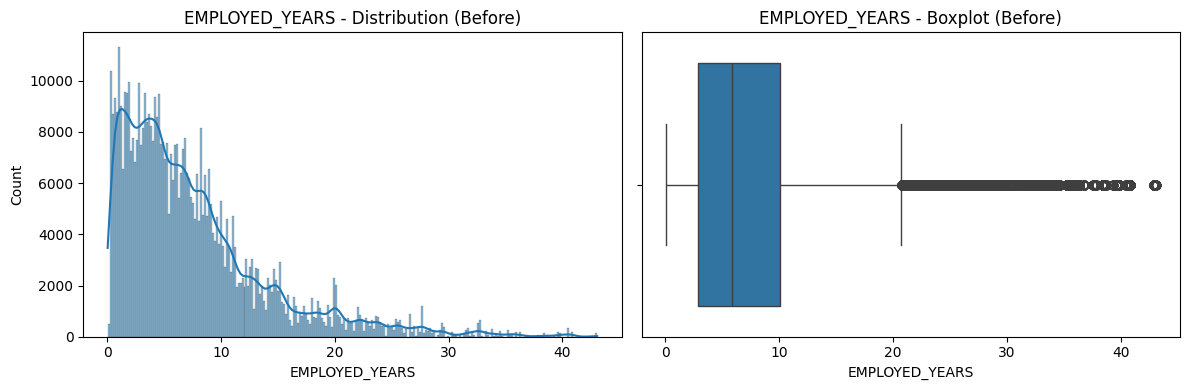

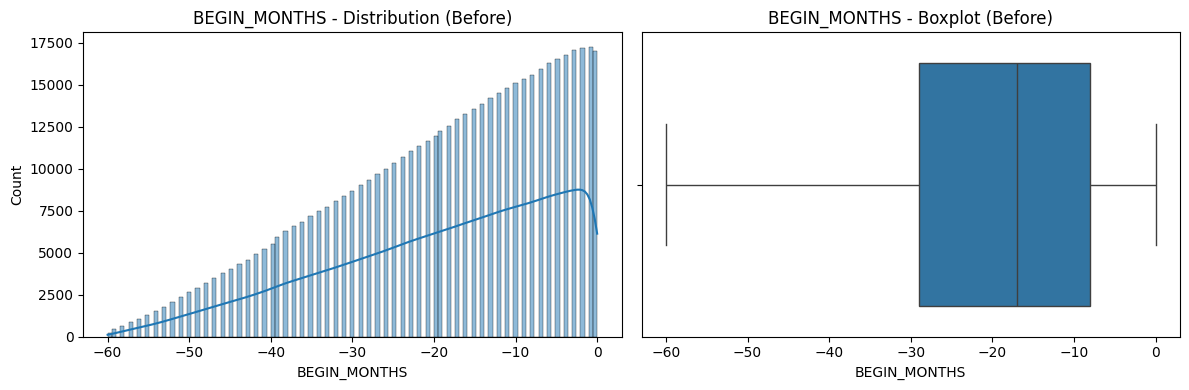

In [ ]:
# Checking for Outliers

import matplotlib.pyplot as plt
import seaborn as sns

def plot_before(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} - Distribution (Before)")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} - Boxplot (Before)")

    plt.tight_layout()
    plt.show()

for col in num_cols:
    plot_before(df, col)

In [ ]:
# Defining Outliers
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
df_clean = df.copy()

for col in num_cols:
    df_clean = remove_outliers_iqr(df_clean, col)

In [ ]:
# Cheking How many Rows Removed
print("Original rows:", df.shape[0])
print("After outlier removal:", df_clean.shape[0])
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original rows: 537667
After outlier removal: 482994
Rows removed: 54673


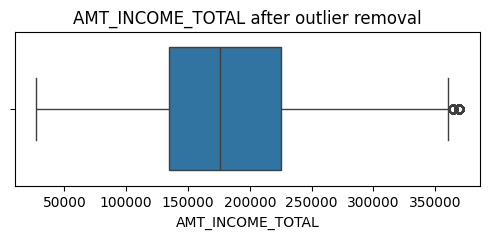

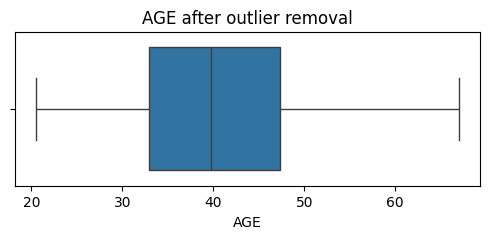

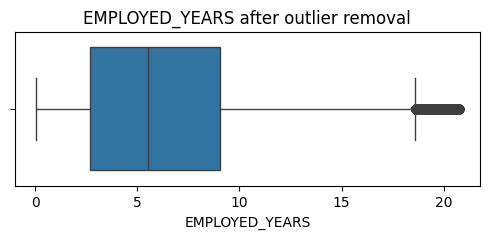

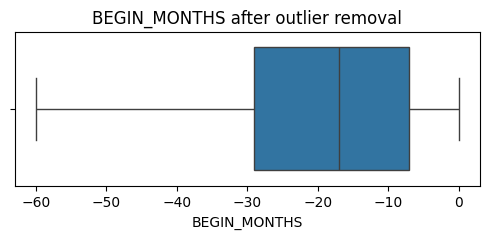

In [ ]:
# Checking Visually
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df_clean[col])
    plt.title(f"{col} after outlier removal")
    plt.show()

In [ ]:
# removing Unneccesory cols
drop_cols = [
    "FLAG_MOBIL",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
    "ID"
]

df_clean = df_clean.drop(columns=drop_cols)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 482994 entries, 0 to 537665
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          482994 non-null  object 
 1   FLAG_OWN_CAR         482994 non-null  object 
 2   FLAG_OWN_REALTY      482994 non-null  object 
 3   CNT_CHILDREN         482994 non-null  object 
 4   AMT_INCOME_TOTAL     482994 non-null  float64
 5   NAME_EDUCATION_TYPE  482994 non-null  object 
 6   NAME_FAMILY_STATUS   482994 non-null  object 
 7   NAME_HOUSING_TYPE    482994 non-null  object 
 8   DAYS_BIRTH           482994 non-null  int64  
 9   DAYS_EMPLOYED        482994 non-null  int64  
 10  JOB                  482994 non-null  object 
 11  BEGIN_MONTHS         482994 non-null  int64  
 12  STATUS               482994 non-null  object 
 13  TARGET               482994 non-null  int64  
 14  AGE                  482994 non-null  float64
 15  EMPLOYED_YEARS       4

In [ ]:
df_clean.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,JOB,BEGIN_MONTHS,STATUS,TARGET,AGE,EMPLOYED_YEARS
0,F,Y,N,2+ children,270000.0,Secondary / secondary special,Married,With parents,13258,2300,Managers,-6,C,0,36.323288,6.301370
1,F,N,N,No children,81000.0,Secondary / secondary special,Single / not married,House / apartment,17876,377,Private service staff,-4,0,0,48.975342,1.032877
2,M,Y,Y,No children,270000.0,Higher education,Married,House / apartment,19579,1028,Laborers,0,C,0,53.641096,2.816438
3,F,Y,Y,1 children,112500.0,Secondary / secondary special,Married,House / apartment,15109,1956,Core staff,-3,0,0,41.394521,5.358904
4,M,Y,Y,2+ children,139500.0,Secondary / secondary special,Married,House / apartment,17281,5578,Drivers,-29,0,0,47.345205,15.282192


In [ ]:
df_clean["TARGET"].value_counts()
df_clean.shape

(482994, 16)

In [ ]:
df_clean['STATUS'].value_counts()

,count
STATUS,
C,204251
0,179227
X,91948
1,5838
5,939
2,503
3,159
4,129


In [ ]:
df_clean["TARGET"].value_counts(dropna=False)

,count
TARGET,
0,481264
1,1730


In [ ]:
leakage_cols = ["BEGIN_MONTHS", "STATUS"]

df_clean = df_clean.drop(columns=leakage_cols)

In [ ]:

X = df_clean.drop("TARGET", axis=1)
y = df_clean["TARGET"]

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",  # handles class imbalance
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred_lr = log_model.predict(X_test_scaled)
y_prob_lr = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred_lr))
print(roc_auc_score(y_test, y_prob_lr))
print(confusion_matrix(y_test, y_pred_lr))

0.6487541278895227
0.7065972690348995
[[62439 33814]
 [  116   230]]


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Train-test split already done
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scale AFTER SMOTE
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Train model
log_smote = LogisticRegression(max_iter=1000)
log_smote.fit(X_train_res_scaled, y_train_res)

# Evaluate
y_pred_smote = log_smote.predict(X_test_scaled)
y_prob_smote = log_smote.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

print(confusion_matrix(y_test, y_pred_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

[[68367 27886]
 [  135   211]]
Accuracy: 0.7099245333802627
ROC-AUC: 0.700919403818297


In [ ]:
#   #Random Forest
# from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=10,
#     random_state=42
# )

# rf_model.fit(X_train_scaled, y_train)

# y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",        # syllabus topic
    max_depth=5,             # controls overfitting
    min_samples_leaf=20,     # stabilizes leaves
    class_weight="balanced", # handles imbalance
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=20, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_dt)

0.8961479932504477

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_dt)

array([[86376,  9877],
       [  155,   191]])

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob_dt)

np.float64(0.7842904108266214)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95     96253
           1       0.02      0.55      0.04       346

    accuracy                           0.90     96599
   macro avg       0.51      0.72      0.49     96599
weighted avg       0.99      0.90      0.94     96599

